In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load dataset
df = pd.read_csv("Updated Quality of Life Data.csv")

In [4]:
df.head()

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
df.describe()


,id,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,15000.50000,9.211857,5.964582,7.364192,1.459726,79.85060
std,2886.89568,2.903739,3.152097,2.214386,0.954428,12.02562
min,10001.00000,0.010000,0.000000,0.000000,0.000000,25.00000
25%,12500.75000,7.740000,3.890000,6.310000,0.650000,74.00000
50%,15000.50000,8.960000,5.830000,7.390000,1.440000,81.00000
75%,17500.25000,10.440000,7.670000,8.470000,2.250000,88.00000
max,20000.00000,23.970000,23.930000,19.980000,5.930000,100.00000


In [8]:
df["total_hours"] = (
    df["avg_work_hours_per_day"] +
    df["avg_rest_hours_per_day"] +
    df["avg_sleep_hours_per_day"] +
    df["avg_exercise_hours_per_day"]
)

df["total_hours"].describe()


count    10000.000000
mean        24.000357
std          0.013602
min         23.990000
25%         24.000000
50%         24.000000
75%         24.000000
max         24.650000
Name: total_hours, dtype: float64

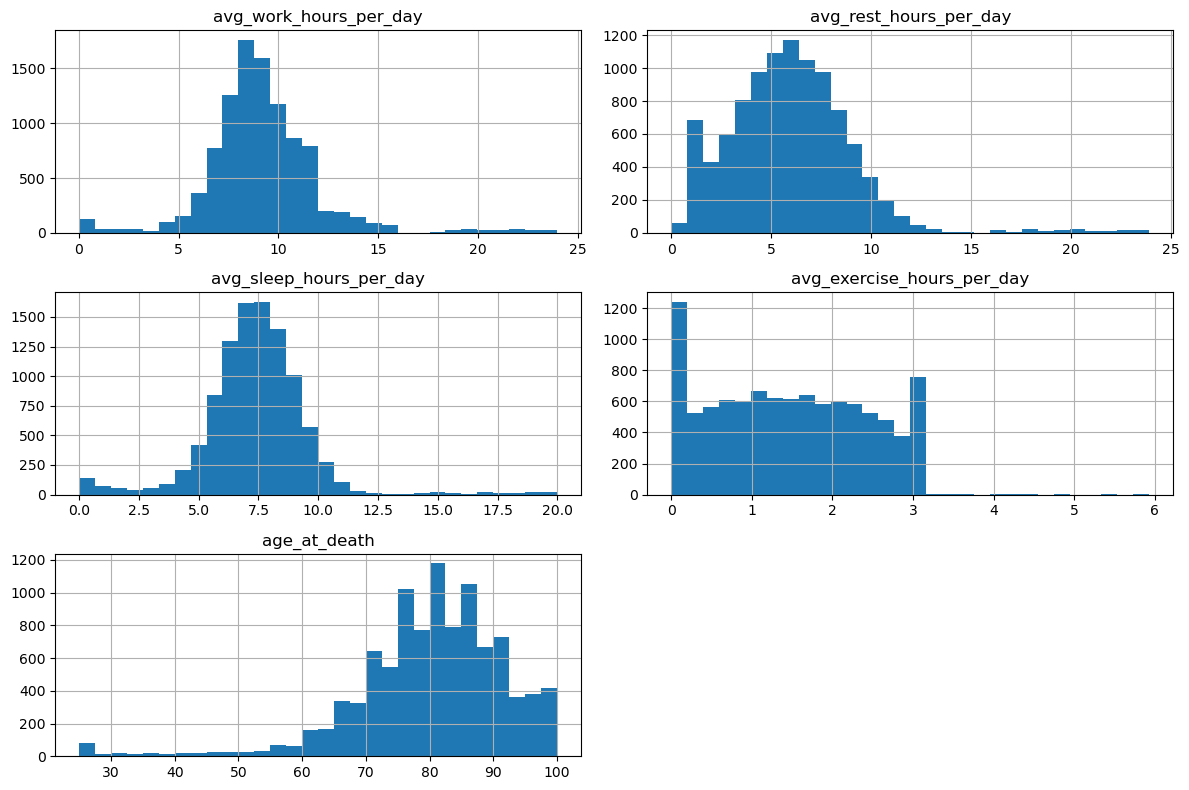

In [9]:
numeric_cols = [
    'avg_work_hours_per_day',
    'avg_rest_hours_per_day',
    'avg_sleep_hours_per_day',
    'avg_exercise_hours_per_day',
    'age_at_death'
]

df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()


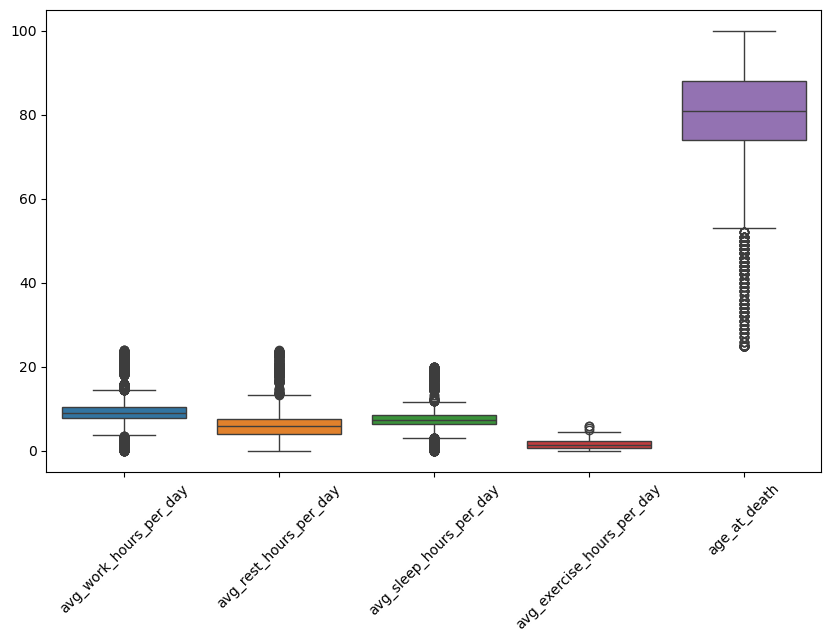

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()


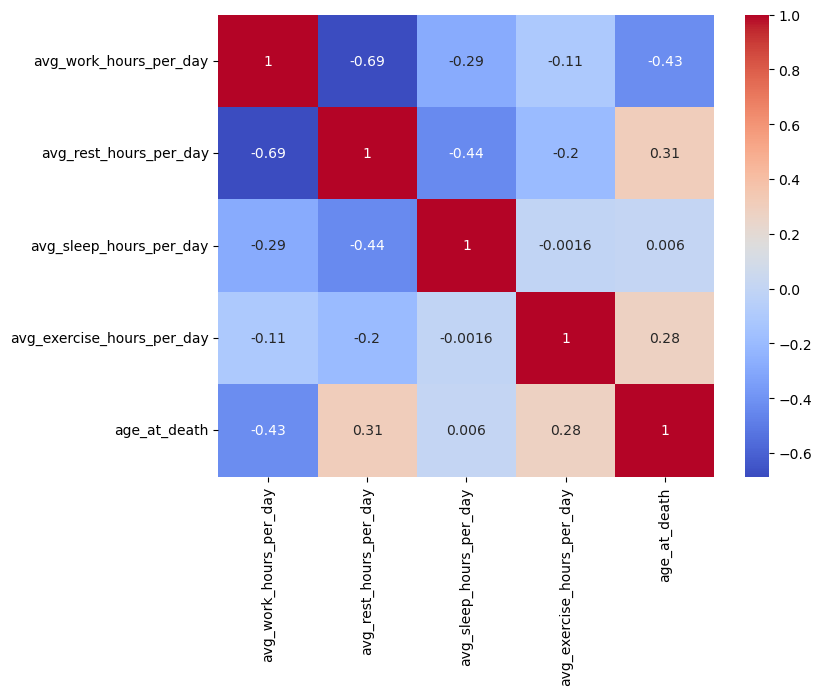

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()


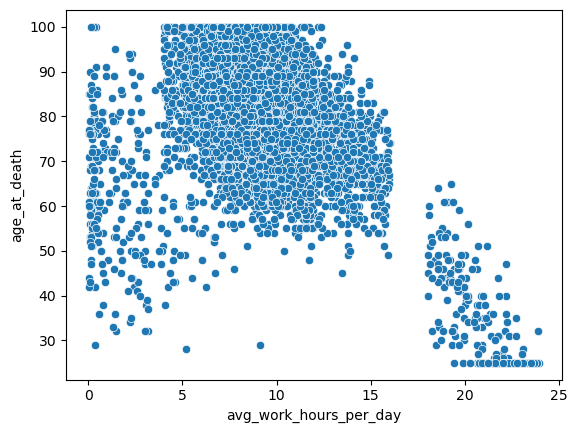

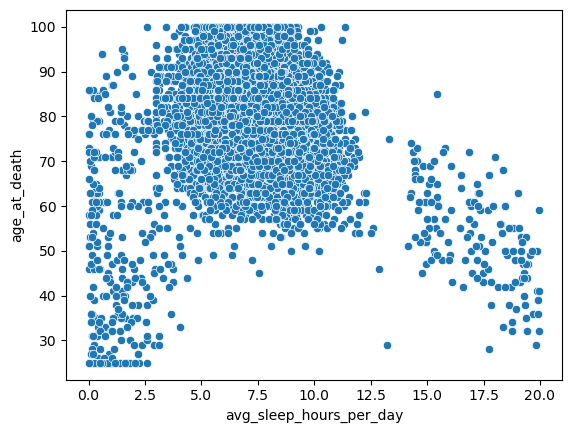

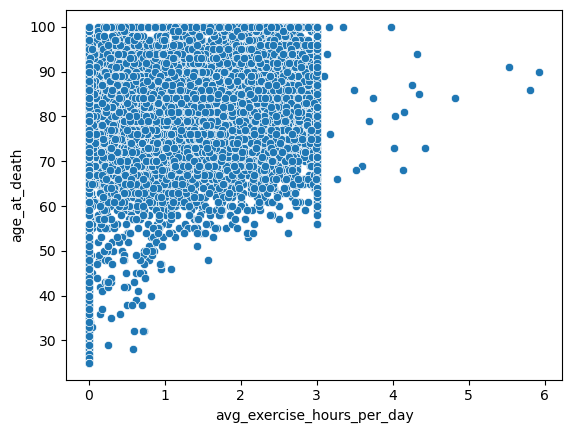

In [12]:
sns.scatterplot(x='avg_work_hours_per_day', y='age_at_death', data=df)
plt.show()

sns.scatterplot(x='avg_sleep_hours_per_day', y='age_at_death', data=df)
plt.show()

sns.scatterplot(x='avg_exercise_hours_per_day', y='age_at_death', data=df)
plt.show()


In [13]:
df.groupby('gender')['age_at_death'].mean()
df.groupby('occupation_type')['age_at_death'].mean().sort_values(ascending=False)


occupation_type
Artist               83.193314
Teacher              83.188482
Retail Worker        82.462079
Freelancer           81.149100
Office Worker        80.859603
Technician           80.633978
Engineer             80.476048
Consultant           80.261972
Scientist            80.139566
Driver               79.002759
Manual Laborer       78.972644
Healthcare Worker    78.222720
Manager              76.556485
Entrepreneur         72.172911
Name: age_at_death, dtype: float64

In [16]:
df[['avg_work_hours_per_day',
    'avg_rest_hours_per_day',
    'avg_sleep_hours_per_day',
    'avg_exercise_hours_per_day',
    'age_at_death']].corr()



,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
avg_work_hours_per_day,1.000000,-0.685748,-0.289157,-0.107078,-0.428623
avg_rest_hours_per_day,-0.685748,1.000000,-0.436039,-0.203204,0.305016
avg_sleep_hours_per_day,-0.289157,-0.436039,1.000000,-0.001596,0.005955
avg_exercise_hours_per_day,-0.107078,-0.203204,-0.001596,1.000000,0.281921
age_at_death,-0.428623,0.305016,0.005955,0.281921,1.000000


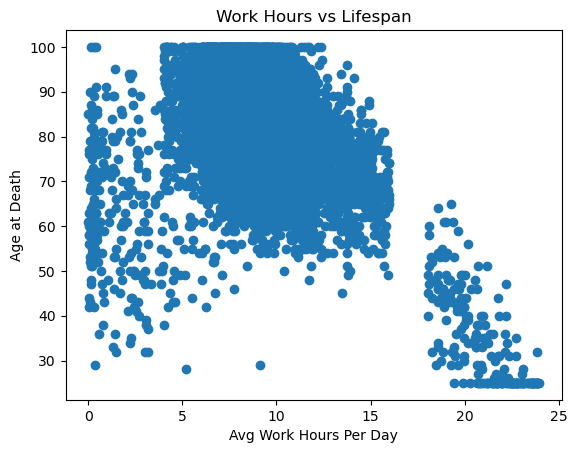

In [17]:
plt.figure()
plt.scatter(df['avg_work_hours_per_day'], df['age_at_death'])
plt.xlabel('Avg Work Hours Per Day')
plt.ylabel('Age at Death')
plt.title('Work Hours vs Lifespan')
plt.show()


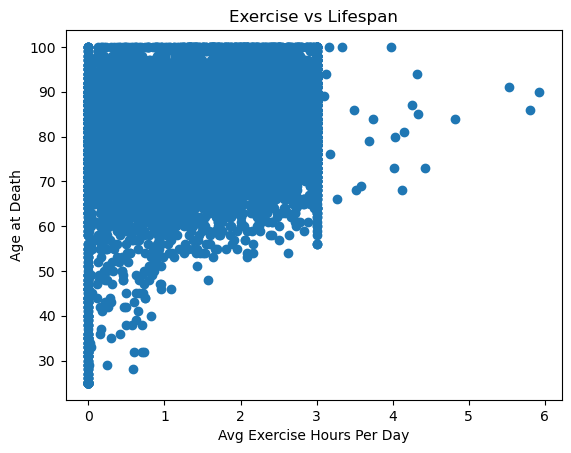

In [18]:
plt.figure()
plt.scatter(df['avg_exercise_hours_per_day'], df['age_at_death'])
plt.xlabel('Avg Exercise Hours Per Day')
plt.ylabel('Age at Death')
plt.title('Exercise vs Lifespan')
plt.show()


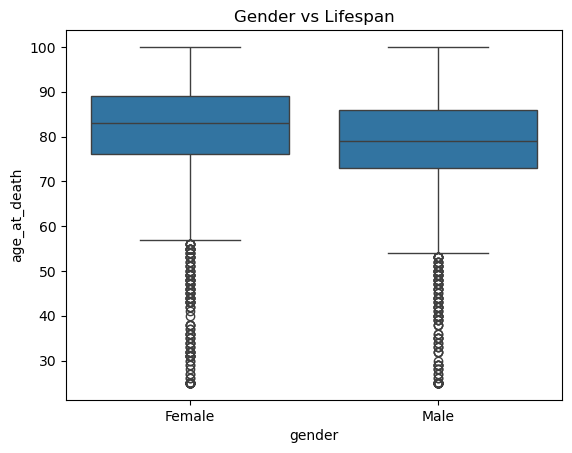

In [19]:
plt.figure()
sns.boxplot(x='gender', y='age_at_death', data=df)
plt.title('Gender vs Lifespan')
plt.show()


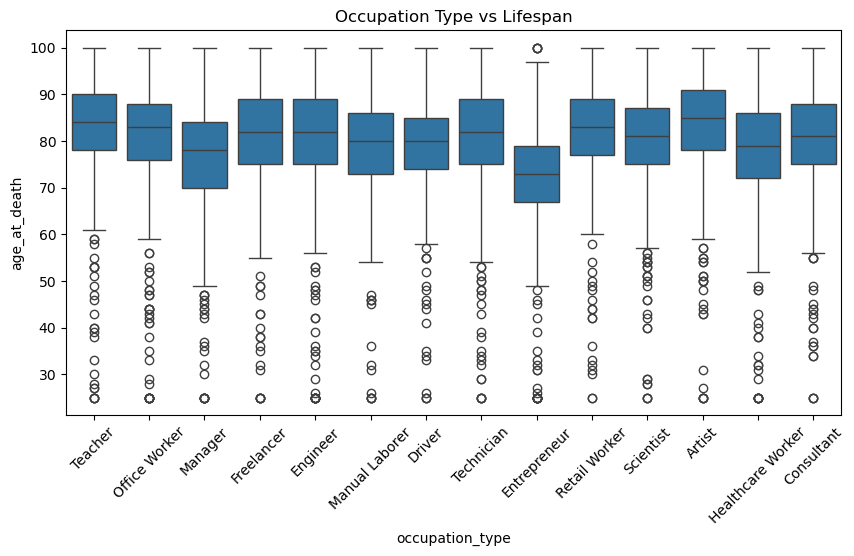

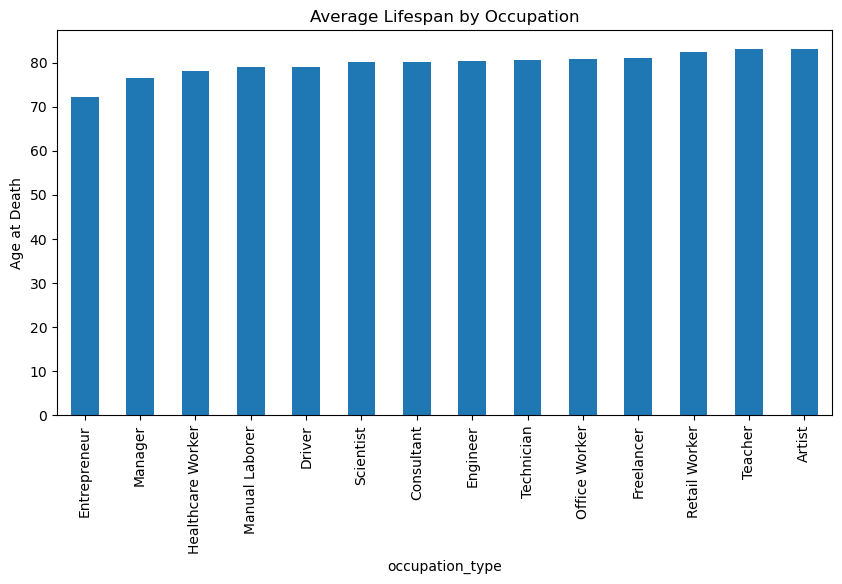

In [21]:
occupation_life = df.groupby('occupation_type')['age_at_death'].mean().sort_values()

plt.figure(figsize=(10,5))
occupation_life.plot(kind='bar')
plt.title('Average Lifespan by Occupation')
plt.ylabel('Age at Death')
plt.show()


# Conclusion
This analysis explored the relationship between lifestyle factors and longevity using a synthetic dataset of 10,000 individuals. Results indicate that excessive work hours are negatively correlated with lifespan, while moderate rest and regular exercise show a positive association with longevity. Sleep hours demonstrate diminishing returns, suggesting that balance is more important than extremes. Occupational analysis reveals noticeable differences in average lifespan, likely reflecting varying stress and activity levels across professions. Overall, the findings highlight that a balanced daily routine plays a critical role in promoting a longer lifespan.



In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

df = pd.read_csv('Updated Quality of Life Data.csv')

username = "root"
password = quote_plus("")   # 🔥 password encoded
host = "localhost"
port = "3306"
database = "work_life_balance"

engine = create_engine(
    f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}"
)
# Step 2: Load DataFrame into MySQL
table_name = "work_life_balance"

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")


Data successfully loaded into table 'work_life_balance' in database 'work_life_balance'.
